In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nikhilitaudiya/mcq-saved-weights/best_distilbert_model.pt
/kaggle/input/datasets/nikhilitaudiya/mcq-saved-weights/best_bert_model.pt
/kaggle/input/datasets/nikhilitaudiya/mcq-saved-weights/best_mlp_model.pt
/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# DUMMY SUBMISSION:

In [2]:
# import pandas as pd

# submission_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
# submission_df.to_csv("submission.csv",index=False)

# IMPORTING ALL DEPENDENCIES:

In [3]:
import os
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForMultipleChoice
from torch.optim import AdamW
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack as scipy_hstack
import wandb

warnings.filterwarnings("ignore")

In [4]:
# Seeding for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# SET DEVICE:

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device configured: {device}")

Device configured: cuda


#  WANDB LOGIN :

In [6]:
try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    WB_KEY = user_secrets.get_secret("wandb-key")
    wandb.login(key=WB_KEY)
except Exception as e:
    print("WandB login key not found.", e)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


# LOADING ALL DATASETS:

In [7]:
train_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
submission_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

# EXPLONATORY DATA ANALYSIS:

#  DISPLAY FIRST FIVE ROWS OF TRAIN_DF:

In [8]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [9]:
test_df.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [11]:
print("#" * 50)
print(f"TRAIN_DF SHAPE: {train_df.shape}")
print(f"TEST_DF SHAPE: {test_df.shape}")

print("#" * 50)
print(f"TRAIN_DF COLUMNS: {train_df.columns}")
print(f"TEST_DF COLUMNS: {test_df.columns}")


##################################################
TRAIN_DF SHAPE: (2000, 8)
TEST_DF SHAPE: (500, 7)
##################################################
TRAIN_DF COLUMNS: Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer'], dtype='object')
TEST_DF COLUMNS: Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E'], dtype='object')


# Target class distribution

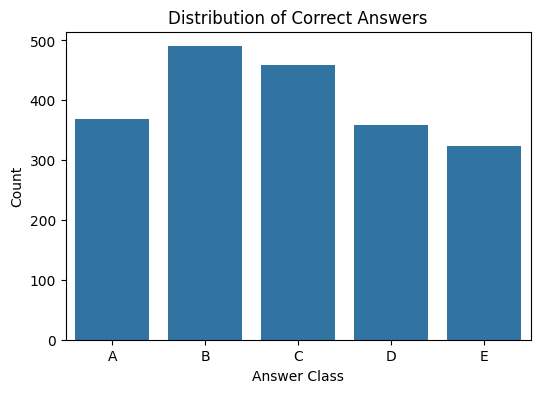

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='answer', data=train_df, order=['A', 'B', 'C', 'D', 'E'])
plt.title("Distribution of Correct Answers")
plt.xlabel("Answer Class")
plt.ylabel("Count")
plt.show()

# IDENTIFY AND HANDLE DUPLICATES

In [13]:
duplicate_count = train_df.duplicated(subset=['prompt']).sum()
print(f"Duplicate prompts in train dataset: {duplicate_count}")

train_df = train_df.drop_duplicates(subset=['prompt']).reset_index(drop=True)
print(f"Cleaned dataset size : {len(train_df)}")

Duplicate prompts in train dataset: 242
Cleaned dataset size : 1758


# IDENTIFY AND HANDLE MISSING VALUES

In [14]:
print("#" * 50)
print(f"MISSING VALUE IN TRAIN_DF:{train_df.isnull().sum()}")
print("#" * 50)
print(f"MISSING VALUE IN TEST_DF:{test_df.isnull().sum()}")

columns = ["prompt", "A", "B", "C", "D", "E"]
for column in columns:
    train_df[column] = train_df[column].fillna("")
    if column in test_df.columns:
        test_df[column] = test_df[column].fillna("")

##################################################
MISSING VALUE IN TRAIN_DF:id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64
##################################################
MISSING VALUE IN TEST_DF:id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


In [15]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


# SPLITTING OF DATASET

In [16]:
train_split, val_split = train_test_split(
    train_df, 
    train_size=0.8, 
    random_state=42, 
    stratify=train_df['answer']
)

# TF-IDF VECTORIZER | COSINE SIMILARITIES | MAP@3

In [17]:
all_columns=['prompt','A','B','C','D','E']
combined_text_of_all_columns = train_df[all_columns].fillna('').astype(str).agg(' '.join, axis=1)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english",ngram_range=(1,2), max_features=1000)
vectorizer.fit(combined_text_of_all_columns)

TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english')

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

scores = []

for index, row in train_df.iterrows():
    prompt_text = row['prompt']
    actual_answer_text = row['answer']
    
    prompt_vector = vectorizer.transform([prompt_text])
    
    # Calculate similarity for each of the 5 options
    similarities = {}
    for option in ['A', 'B', 'C', 'D', 'E']:
        option_text = row[option]
        option_vector = vectorizer.transform([option_text])
        
        score = cosine_similarity(prompt_vector, option_vector)[0][0]
        similarities[option] = score
        
    # print(f"INDEX : {index}") 
    # print(f"ACTUAL ANSWER : {actual_answer_text}")
    # print(f"COSINE SIMILARITIES : {similarities}") 
    
    sorted_options = sorted(similarities, key=similarities.get, reverse=True)
    # print(f"SORTED_OPTIONS : {sorted_options}")
    
    top_3 = sorted_options[:3]
    # print(f"TOP3 VALUES : {top_3}")
    
    if index <10:
        print(f"Index: {index} | Actual: {actual_answer_text} | Predicted Top3: {top_3}")
    
    if actual_answer_text == top_3[0]:
        scores.append(1.0)
    elif actual_answer_text == top_3[1]:
        scores.append(0.5)
    elif actual_answer_text == top_3[2]:
        scores.append(1/3)
    else:
        scores.append(0.0)

final_map3 = np.mean(scores)
round(final_map3 ,4)

Index: 0 | Actual: B | Predicted Top3: ['D', 'C', 'B']
Index: 1 | Actual: A | Predicted Top3: ['A', 'C', 'B']
Index: 2 | Actual: C | Predicted Top3: ['A', 'B', 'C']
Index: 3 | Actual: B | Predicted Top3: ['D', 'C', 'B']
Index: 4 | Actual: A | Predicted Top3: ['D', 'E', 'C']
Index: 5 | Actual: C | Predicted Top3: ['A', 'B', 'C']
Index: 6 | Actual: E | Predicted Top3: ['A', 'B', 'E']
Index: 7 | Actual: A | Predicted Top3: ['C', 'D', 'B']
Index: 8 | Actual: A | Predicted Top3: ['A', 'B', 'C']
Index: 9 | Actual: A | Predicted Top3: ['A', 'C', 'E']


np.float64(0.3421)

# MODEL1 : TF-IDF + LOGISTIC REGRESSION

# INITIALIZE WANDB RUN

In [19]:
hyperparameters = {
     "model_type": "TFIDF_Logistic_Regression",
     "word_max_features": 40000,
     "char_max_features": 60000,
     "word_ngram_range": (1, 2),
     "char_ngram_range": (3, 5),
     "C_regularization": 1.5,
     "max_iter": 1000,
     "solver": "liblinear"
}

wandb.init(
     project="23f2002113-t22026",
     name="tfidf-logistic-regression",
     config=hyperparameters
)

wandb: setting up run d7k3qu9p
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260713_022033-d7k3qu9p
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run tfidf-logistic-regression
wandb: ⭐️ View project at https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026
wandb: 🚀 View run at https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026/runs/d7k3qu9p


# MAP@3 calculator:

In [20]:
def calculate_map3(y_true, y_pred_probs):
    scores = []
    for true_index, probs in zip(y_true, y_pred_probs):
        top_3_indices = np.argsort(-probs)[:3]
        
        if true_index == top_3_indices[0]:
            scores.append(1.0)
        elif true_index == top_3_indices[1]:
            scores.append(0.5)
        elif true_index == top_3_indices[2]:
            scores.append(1/3)
        else:
            scores.append(0.0)
            
    return np.mean(scores)

In [21]:
def process_ranking_data(df, is_test=False):
    texts = []
    labels = []
    options_list = ['A', 'B', 'C', 'D', 'E']
    
    for _, row in df.iterrows():
        prompt = row['prompt']
        for opt in options_list:
            # Pair prompt with option text
            combined_text = f"{prompt} [SEP] {row[opt]}"
            texts.append(combined_text)
            
            if not is_test:
                labels.append(1 if row['answer'] == opt else 0)
                
    return texts, (np.array(labels) if not is_test else None)


# Prepare text raw representations
train_texts, train_labels = process_ranking_data(train_split, is_test=False)
val_texts, val_labels = process_ranking_data(val_split, is_test=False)
test_texts, _ = process_ranking_data(test_df, is_test=True)


# DUAL TF-IDF FEATURE EXTRACTION
word_vectorizer = TfidfVectorizer(
     ngram_range=tuple(wandb.config.word_ngram_range), 
     max_features=wandb.config.word_max_features, 
     sublinear_tf=True, 
     stop_words='english'
)

char_vectorizer = TfidfVectorizer(
     analyzer='char', 
     ngram_range=tuple(wandb.config.char_ngram_range), 
     max_features=wandb.config.char_max_features, 
     sublinear_tf=True
)

     
# # Fit vectorizers on training splits
word_vectorizer.fit(train_texts)
char_vectorizer.fit(train_texts)

# Combine representations
X_train_lr = scipy_hstack([word_vectorizer.transform(train_texts), char_vectorizer.transform(train_texts)]).tocsr()
X_val_lr =scipy_hstack([word_vectorizer.transform(val_texts), char_vectorizer.transform(val_texts)]).tocsr()
X_test_lr = scipy_hstack([word_vectorizer.transform(test_texts), char_vectorizer.transform(test_texts)]).tocsr()


#Training regression model
lr_model = LogisticRegression(
    C=wandb.config.C_regularization, 
    max_iter=wandb.config.max_iter, 
    solver=wandb.config.solver
)

lr_model.fit(X_train_lr, train_labels)


# Evaluate Validation
val_preds_lr = lr_model.predict_proba(X_val_lr)[:, 1]
val_preds_matrix_lr = val_preds_lr.reshape(-1, 5)
val_labels_matrix_lr = train_labels[:len(val_preds_matrix_lr)*5].reshape(-1, 5)


pred_indices_lr = np.argmax(val_preds_matrix_lr, axis=1)
true_indices_lr = np.argmax(val_labels_matrix_lr, axis=1)


accuracy_lr = accuracy_score(true_indices_lr, pred_indices_lr)
f1_lr = f1_score(true_indices_lr, pred_indices_lr, average='macro')
map3_lr = calculate_map3(true_indices_lr, val_preds_matrix_lr)


print(f"\n--- EVALUATION RESULTS  ---")
print(f"Validation Accuracy: {accuracy_lr:.4f}")
print(f"Validation F1-Score: {f1_lr:.4f}")
print(f"Validation MAP@3 Score: {map3_lr:.4f}")


#WANDB LOGS 
wandb.log({
    "val_accuracy": accuracy_lr,
    "val_f1_score": f1_lr,
    "val_map3": map3_lr
})

# Close the WandB run session
wandb.finish()

wandb: updating run metadata



--- EVALUATION RESULTS  ---
Validation Accuracy: 0.2330
Validation F1-Score: 0.2242
Validation MAP@3 Score: 0.3845


wandb: uploading config.yaml; uploading output.log; uploading wandb-summary.json
wandb: uploading config.yaml; uploading wandb-summary.json
wandb: uploading history steps 0-0, summary, console lines 0-4
wandb: 
wandb: Run history:
wandb: val_accuracy ▁
wandb: val_f1_score ▁
wandb:     val_map3 ▁
wandb: 
wandb: Run summary:
wandb: val_accuracy 0.23295
wandb: val_f1_score 0.22422
wandb:     val_map3 0.38447
wandb: 
wandb: 🚀 View run tfidf-logistic-regression at: https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026/runs/d7k3qu9p
wandb: ⭐️ View project at: https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260713_022033-d7k3qu9p/logs


# MODEL 2-PRETRAINED MODEL(DISTILBERT-BASE-UNCASED)

# TRANSFORMER DATASET:

In [22]:
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=224, is_test=False):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test
        self.options = ['A', 'B', 'C', 'D', 'E']
        self.labels_map = {option: index for index, option in enumerate(self.options)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        prompt = row['prompt']
        
        # We pair the prompt with all 5 options individually
        prompts = [row['prompt']] * 5
        choices = [str(row[option]) for option in self.options]
        
        # Convert text pairs into sequence arrays
        features = self.tokenizer(
            prompts,
            choices,
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors="pt"
        )
        
        # Format tensors so PyTorch can bundle them into batches
        item = {key: value.squeeze(0) for key, value in features.items()}
        
        if not self.is_test:
            # Map correct string answer (e.g., 'B') to numerical index (e.g., 1)
            item['label'] = torch.tensor(self.labels_map[row['answer']], dtype=torch.long)
            
        return item     

# CONFIGURATION

In [23]:
# HYPERPARAMETERS
hyperparameters = {
  "model_name": "distilbert-base-uncased",
   "learning_rate": 2e-5,
   "batch_size": 4,  
   "epochs": 3,
   "max_len": 224
}

# Initialize your Weights & Biases 
wandb.init(
   project="23f2002113-t22026",
   name="distilbert-mcq",
   config=hyperparameters
)


# import tokenizer and  pretrained multiple-choice model
distil_tokenizer = AutoTokenizer.from_pretrained(wandb.config.model_name)
distil_model = AutoModelForMultipleChoice.from_pretrained(wandb.config.model_name).to(device)

# PyTorch DataLoaders (it converts our data into batches of size 4)
train_dataset = MCQDataset(train_split, distil_tokenizer, max_len=wandb.config.max_len)
val_dataset = MCQDataset(val_split, distil_tokenizer, max_len=wandb.config.max_len)

distil_train_loader = DataLoader(train_dataset, batch_size=wandb.config.batch_size, shuffle=True)
distil_val_loader = DataLoader(val_dataset, batch_size=wandb.config.batch_size, shuffle=False)

# Apply optimizer to adjust weights during training
distil_optimizer = AdamW(distil_model.parameters(), lr=wandb.config.learning_rate)


wandb: setting up run 5h2j6oqx
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260713_022047-5h2j6oqx
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run distilbert-mcq
wandb: ⭐️ View project at https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026
wandb: 🚀 View run at https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026/runs/5h2j6oqx


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForMultipleChoice LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# MODEL TRAINING AND VALIDATION PHASE

In [24]:
# best_distil_map3 = 0.0

# for epoch in range(wandb.config.epochs):
#     # --- TRAINING PHASE ---
#     distil_model.train()
#     total_loss = 0
    
#     for batch in distil_train_loader:
#         distil_optimizer.zero_grad()
        
#         # Send numerical batch IDs to GPU
#         input_ids = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels = batch['label'].to(device)
        
#         # Forward pass through model to get loss and scores
#         outputs = distil_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
#         loss = outputs.loss

#         # Backward pass (calculates changes) and optimizer step (applies changes)
#         loss.backward()
#         distil_optimizer.step()
#         total_loss += loss.item()
    
    
#     # --- VALIDATION PHASE (EVALUATION) ---
#     distil_model.eval()
#     val_preds_distil = []
#     val_targets_distil = []
    
    # with torch.no_grad():
    #     for batch in distil_val_loader:
            
    #         # Send numerical batch IDs to GPU
    #         input_ids = batch['input_ids'].to(device)
    #         attention_mask = batch['attention_mask'].to(device)
    #         labels = batch['label'].to(device)
            
    #         outputs = distil_model(input_ids=input_ids, attention_mask=attention_mask)

    #         logits = outputs.logits
    #         probs = torch.softmax(logits, dim=-1).cpu().numpy()
            
    #         val_preds_distil.extend(probs)
    #         val_targets_distil.extend(labels.cpu().numpy())
            
    # val_preds_distil = np.array(val_preds_distil)
    # pred_classes_distil = np.argmax(val_preds_distil, axis=1)

    # #EVALUATION METRICES:
    # acc_distil = accuracy_score(val_targets_distil, pred_classes_distil)
    # f1_distil = f1_score(val_targets_distil, pred_classes_distil, average='macro')
    # map3_distil = calculate_map3(val_targets_distil, val_preds_distil)
    
    # print(f"DistilBERT Epoch {epoch+1} | Loss: {total_loss/len(distil_train_loader):.4f} | Val Acc: {acc_distil:.4f} | Val F1: {f1_distil:.4f} | Val MAP@3: {map3_distil:.4f}")

    # # Save model weights only if validation MAP@3 score improves
    # if map3_distil > best_distil_map3:
    #     best_distil_map3 = map3_distil
    #     torch.save(distil_model.state_dict(), "best_distilbert_model.pt")
    #     print("--> Saved best DistilBERT checkpoint.")

    
    # #wandb log
    # wandb.log({
    #     "epoch": epoch+1, 
    #     "train_loss": total_loss/len(distil_train_loader), 
    #     "val_accuracy": acc_distil, 
    #     "val_f1_score": f1_distil,
    #     "val_map3": map3_distil
    # })
    

# Close the WandB run session
wandb.finish()

wandb: updating run metadata
wandb: uploading wandb-summary.json; uploading config.yaml
wandb: uploading summary, console lines 0-16
wandb: 🚀 View run distilbert-mcq at: https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026/runs/5h2j6oqx
wandb: ⭐️ View project at: https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260713_022047-5h2j6oqx/logs


# MODEL 3-PRETRAINED MODEL(BERT-BASE-UNCASED)

# CONFIGURATION

In [25]:
# HYPERPARAMETERS
hyperparameters = {
  "model_name": "bert-base-uncased",
   "learning_rate": 2e-5,
   "batch_size": 4,  
   "epochs": 3,
   "max_len": 224
}

# Initialize your Weights & Biases 
wandb.init(
   project="23f2002113-t22026",
   name="bert-base-mcq",
   config=hyperparameters
)


# import tokenizer and  pretrained multiple-choice model
bert_tokenizer = AutoTokenizer.from_pretrained(wandb.config.model_name)
bert_model = AutoModelForMultipleChoice.from_pretrained(wandb.config.model_name).to(device)

# PyTorch DataLoaders (it converts our data into batches of size 4)
train_dataset = MCQDataset(train_split, bert_tokenizer, max_len=wandb.config.max_len)
val_dataset = MCQDataset(val_split, bert_tokenizer, max_len=wandb.config.max_len)

bert_train_loader = DataLoader(train_dataset, batch_size=wandb.config.batch_size, shuffle=True)
bert_val_loader = DataLoader(val_dataset, batch_size=wandb.config.batch_size, shuffle=False)

# Apply optimizer to adjust weights during training
bert_optimizer = AdamW(bert_model.parameters(), lr=wandb.config.learning_rate)

wandb: setting up run c64dti51
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260713_022103-c64dti51
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run bert-base-mcq
wandb: ⭐️ View project at https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026
wandb: 🚀 View run at https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026/runs/c64dti51


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# MODEL TRAINING AND VALIDATION PHASE:

In [26]:
# best_bert_map3 = 0.0

# for epoch in range(wandb.config.epochs):
#     # --- TRAINING PHASE ---
#     bert_model.train()
#     total_loss = 0
    
#     for batch in bert_train_loader:
#         bert_optimizer.zero_grad()
        
#         # Send numerical batch IDs to GPU
#         input_ids = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         labels = batch['label'].to(device)
        
#         # Forward pass through model to get loss and scores
#         outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
#         loss = outputs.loss

#         # Backward pass (calculates changes) and optimizer step (applies changes)
#         loss.backward()
#         bert_optimizer.step()
#         total_loss += loss.item()
    
    
#     # --- VALIDATION PHASE ---
#     bert_model.eval()
#     val_preds_bert = []
#     val_targets_bert = []
    
#     with torch.no_grad():
#         for batch in bert_val_loader:
            
    #         # Send numerical batch IDs to GPU
    #         input_ids = batch['input_ids'].to(device)
    #         attention_mask = batch['attention_mask'].to(device)
    #         labels = batch['label'].to(device)
            
    #         outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)

    #         logits = outputs.logits
    #         probs = torch.softmax(logits, dim=-1).cpu().numpy()
            
    #         val_preds_bert.extend(probs)
    #         val_targets_bert.extend(labels.cpu().numpy())
            
    # val_preds_bert = np.array(val_preds_bert)
    # pred_classes_bert = np.argmax(val_preds_bert, axis=1)

    # #EVALUATION METRICES:
    # acc_bert = accuracy_score(val_targets_bert, pred_classes_bert)
    # f1_bert = f1_score(val_targets_bert, pred_classes_bert, average='macro')
    # map3_bert = calculate_map3(val_targets_bert, val_preds_bert)
    
    # print(f"DistilBERT Epoch {epoch+1} | Loss: {total_loss/len(bert_train_loader):.4f} | Val Acc: {acc_bert:.4f} | Val F1: {f1_bert:.4f} | Val MAP@3: {map3_bert:.4f}")

    # # Save model weights only if validation MAP@3 score improves
    # if map3_bert > best_bert_map3:
    #     best_bert_map3 = map3_bert
    #     torch.save(bert_model.state_dict(), "best_bert_model.pt")
    #     print("--> Saved best BERT checkpoint.")
        
    # #wandb log
    # wandb.log({
    #     "epoch": epoch+1, 
    #     "train_loss": total_loss/len(bert_train_loader), 
    #     "val_accuracy": acc_bert, 
    #     "val_f1_score": f1_bert,
    #     "val_map3": map3_bert
    # })


# Close the WandB run session
wandb.finish()

wandb: updating run metadata
wandb: uploading wandb-summary.json; uploading config.yaml
wandb: uploading summary, console lines 0-15
wandb: 🚀 View run bert-base-mcq at: https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026/runs/c64dti51
wandb: ⭐️ View project at: https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260713_022103-c64dti51/logs


# MODEL 4-DL MODEL FROM SCRATCH

# DATASET

In [27]:
# We fit a smaller, dedicated TF-IDF (5,000 features) to prevent the MLP from overfitting on the small dataset.
vectorizer_mlp = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_mlp_raw = vectorizer_mlp.fit_transform(train_texts).toarray()
X_val_mlp_raw = vectorizer_mlp.transform(val_texts).toarray()
X_test_mlp_raw = vectorizer_mlp.transform(test_texts).toarray()

class MLPDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

mlp_train_loader = DataLoader(MLPDataset(X_train_mlp_raw, train_labels), batch_size=32, shuffle=True)

class MCQ_MLP(nn.Module):
    def __init__(self, input_dim):
        super(MCQ_MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),  # Higher dropout to avoid overfitting on smaller sample sizes
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.layers(x).squeeze(-1)

wandb.init(
    project="23f2002113-t22026", 
    name="pytorch-mlp-scratch", 
    config={
    "learning_rate": 1e-3,
    "epochs": 5,
    "batch_size": 32
})

actual_input_dim = X_train_mlp_raw.shape[1]
mlp_model = MCQ_MLP(input_dim=actual_input_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=wandb.config.learning_rate)

wandb: setting up run cvjncrws
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260713_022117-cvjncrws
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pytorch-mlp-scratch
wandb: ⭐️ View project at https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026
wandb: 🚀 View run at https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026/runs/cvjncrws


In [28]:
# best_mlp_map3 = 0.0

# for epoch in range(wandb.config.epochs):
#     # --- TRAINING PHASE ---
#     mlp_model.train()
#     epoch_loss = 0
#     for batch_X, batch_y in mlp_train_loader:
#         batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#         optimizer_mlp.zero_grad()
#         predictions = mlp_model(batch_X)
#         loss = criterion(predictions, batch_y)
#         loss.backward()
#         optimizer_mlp.step()
#         epoch_loss += loss.item()
        
#     # Evaluate Validation
#     mlp_model.eval()
    
#     with torch.no_grad():
#         val_preds_mlp = []
#         mlp_val_loader = DataLoader(MLPDataset(X_val_mlp_raw, None), batch_size=128, shuffle=False)
#         for batch_X in mlp_val_loader:
#             preds = torch.sigmoid(mlp_model(batch_X.to(device))).cpu().numpy()
#             val_preds_mlp.extend(preds)
            
#     val_preds_mlp = np.array(val_preds_mlp)
#     val_preds_matrix_mlp = val_preds_mlp.reshape(-1, 5)
#     pred_indices_mlp = np.argmax(val_preds_matrix_mlp, axis=1)
    
#     acc_mlp = accuracy_score(true_indices_lr, pred_indices_mlp)
#     f1_mlp = f1_score(true_indices_lr, pred_indices_mlp, average='macro')
#     map3_mlp = calculate_map3(true_indices_lr, val_preds_matrix_mlp)
    
#     print(f"MLP Epoch {epoch+1} | Loss: {epoch_loss/len(mlp_train_loader):.4f} | Val Acc: {acc_mlp:.4f} | Val F1: {f1_mlp:.4f} | Val MAP@3: {map3_mlp:.4f}")
    
    # # Save checkpoint only if validation MAP@3 improves
    # if map3_mlp > best_mlp_map3:
    #     best_mlp_map3 = map3_mlp
    #     torch.save(mlp_model.state_dict(), "best_mlp_model.pt")
    #     print("--> Saved best MLP checkpoint.")
        
    # wandb.log({
    #     "epoch": epoch+1, 
    #     "train_loss": epoch_loss/len(mlp_train_loader), 
    #     "val_accuracy": acc_mlp, 
    #     "val_f1_score": f1_mlp,
    #     "val_map3": map3_mlp
    # })

# Close the WandB run session
wandb.finish()


wandb: updating run metadata; uploading summary
wandb: updating run metadata
wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading wandb-summary.json; uploading config.yaml
wandb: 🚀 View run pytorch-mlp-scratch at: https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026/runs/cvjncrws
wandb: ⭐️ View project at: https://wandb.ai/23f2002113-indian-institute-of-technology-madras/23f2002113-t22026
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260713_022117-cvjncrws/logs


# UPLOAD SAVED CHECKPOINT INTO KAGGLEHUB

In [29]:
import os
import shutil
import kagglehub

# # 1. Create a local folder for your weights
# local_folder = "./my_saved_weights"
# os.makedirs(local_folder, exist_ok=True)

# # 2. Copy your three trained .pt files into this folder
# shutil.copy("best_mlp_model.pt", f"{local_folder}/best_mlp_model.pt")
# shutil.copy("best_bert_model.pt", f"{local_folder}/best_bert_model.pt")
# shutil.copy("best_distilbert_model.pt", f"{local_folder}/best_distilbert_model.pt")

# # 3. Set your Kaggle Username
# kaggle_username = "nikhilitaudiya" 
# dataset_slug = "mcq-saved-weights"

# print("Uploading weights to Kaggle...")
# kagglehub.dataset_upload(
#     f"{kaggle_username}/{dataset_slug}", 
#     local_folder
# )
# print("Upload complete!")

# INFERENCE AND SUBMISSION PART

In [30]:
print("\n---All 4 Weighted Ensemble Predictions ---")

# 1. Download your weights from KaggleHub
download_path = kagglehub.dataset_download("nikhilitaudiya/mcq-saved-weights")

# 2. Gather Predictions from Logistic Regression 
lr_test_probs = lr_model.predict_proba(X_test_lr)[:, 1]
lr_test_probs_matrix = lr_test_probs.reshape(-1, 5)

# 3. Load and Gather Predictions from DistilBERT
distil_model.load_state_dict(torch.load(f"{download_path}/best_distilbert_model.pt", map_location=device))
distil_model.eval()

distil_test_loader = DataLoader(
    MCQDataset(test_df, distil_tokenizer, max_len=224, is_test=True), 
    batch_size=4, 
    shuffle=False
)

distil_test_probs = []
with torch.no_grad():
    for batch in distil_test_loader:
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = distil_model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        distil_test_probs.extend(probs)
        
distil_test_probs_matrix = np.array(distil_test_probs)

# 4. Load and Gather Predictions from BERT
bert_model.load_state_dict(torch.load(f"{download_path}/best_bert_model.pt", map_location=device))
bert_model.eval()

bert_test_loader = DataLoader(
    MCQDataset(test_df, bert_tokenizer, max_len=224, is_test=True), 
    batch_size=4, 
    shuffle=False
)

bert_test_probs = []
with torch.no_grad():
    for batch in bert_test_loader:
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        bert_test_probs.extend(probs)
        
bert_test_probs_matrix = np.array(bert_test_probs)

#5.Load and Gather Predictions from Scratch Model
mlp_model.load_state_dict(torch.load(f"{download_path}/best_mlp_model.pt", map_location=device))
mlp_model.eval()

mlp_test_loader = DataLoader(
      MLPDataset(X_test_mlp_raw, None),
      batch_size=128, 
      shuffle=False)

mlp_test_probs = []
with torch.no_grad():
    for batch_X in mlp_test_loader:
        
        preds = torch.sigmoid(mlp_model(batch_X.to(device))).cpu().numpy()
        mlp_test_probs.extend(preds)
        
mlp_test_probs_matrix = np.array(mlp_test_probs).reshape(-1, 5)

# Weighted Average Ensemble of your all 4 models
weights = {
    "lr": 0.35,
    "mlp": 0.10,
    "bert": 0.25,
    "distilbert": 0.30
}

final_ensemble_probs = (
    weights["lr"] * lr_test_probs_matrix +
    weights["mlp"] * mlp_test_probs_matrix +
    weights["bert"] * bert_test_probs_matrix +
    weights["distilbert"] * distil_test_probs_matrix
)

# Convert the ensemble probabilities to ordered options list (e.g., "A B C")
options_list = ['A', 'B', 'C', 'D', 'E']
ranked_predictions = []

for probs in final_ensemble_probs:
    top_3_indices = np.argsort(-probs)[:3]
    top_3_labels = [options_list[idx] for idx in top_3_indices]
    ranked_predictions.append(" ".join(top_3_labels))

# Generate final submission.csv
submission_df = pd.DataFrame({
    'id': test_df['id'] if 'id' in test_df.columns else test_df.index,
    'Prediction': ranked_predictions
})

submission_df.to_csv("submission.csv", index=False)
print("File successfully generated and saved to: submission.csv")


---All 4 Weighted Ensemble Predictions ---
File successfully generated and saved to: submission.csv
